# PV–SST Allen Cell: Local Input & Synapse Builder (ChatGPT Refactor)

This notebook is the **local environment** driver for:
- Building Allen Institute biophysical cells (PV, SST, etc.).
- Generating structured synaptic inputs (bio-derived, background, custom).
- Attaching synapses and spike trains using modular Python files in `modules_external/`.

All NEURON cell logic and input generation live in `.py` files inside `modules_external/`.  
This notebook will only:
1. Configure simulation and synapse parameters.
2. Call the appropriate functions/classes from `modules_external/`.
3. Run simulations and visualize results for verification.

A separate notebook will later provide a fully bootstrapped version for Google Colab or fresh environments (5_colab.ipynb).


Bio curve helper available: `load_bio_curve` from `modules_local.bio_curve`.

In [1]:
from modules_local.bio_curve import load_bio_curve
# Dev helper: autoreload modules_local and ensure repo on sys.path
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
repo_root = Path('/home/hrbncv/PV-SST').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
import os, sys, csv, json, h5py, random, math, pickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

from allensdk.api.queries.biophysical_api import BiophysicalApi
from allensdk.model.biophys_sim.config import Config
from allensdk.model.biophysical.utils import Utils


# from modules_local import download_cell

from modules_local import load_cell
from modules_local import geometry
from modules_local import inputs
from modules_local import synapses

from modules_local import run_sim
from modules_local import plotting


--No graphics will be displayed.


In [3]:
# Select the cell/tune and move into the tune directory (legacy behavior)
cell_name = 'PV'  # SST, SST2, PV, PN
tunes_dir = 'tunes'
model_dir = 'seg_tuned'

tune_dir = Path('cells') / cell_name / tunes_dir / model_dir
if not tune_dir.is_dir():
    raise FileNotFoundError(f'Expected tune dir not found: {tune_dir}')
os.chdir(tune_dir)
print('CWD:', Path.cwd())

# Defaults from cell_configs (fallback if sim_config.json is missing)
cell_cfg_defaults = {}
cell_cfg_path = Path('cell_configs') / 'cell_config.json'
if cell_cfg_path.is_file():
    cell_cfg_defaults = json.loads(cell_cfg_path.read_text())

specimen_id = cell_cfg_defaults.get('specimen_id')
model_type = cell_cfg_defaults.get('model_type', 'perisomatic')
soma_diam_multiplier = float((cell_cfg_defaults.get('tuning') or {}).get('soma_diam_multiplier', 1.0))

# Override from sim_config.json when available
sim_cfg_path = Path('sim_config.json')
sim_cfg_preview = None
if sim_cfg_path.is_file():
    sim_cfg_preview = json.loads(sim_cfg_path.read_text())
    specimen_id = sim_cfg_preview.get('specimen_id', specimen_id)
    model_type = sim_cfg_preview.get('model_type', model_type)
    soma_diam_multiplier = float(sim_cfg_preview.get('soma_diam_multiplier', soma_diam_multiplier))


CWD: /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned


In [4]:
from neuron import h
h.load_file("stdrun.hoc")  # Required to use h.run()
h.nrn_load_dll("modfiles/x86_64/.libs/libnrnmech.so")


1.0

In [5]:
# Load in-vivo firing-rate curve once (PN)
from modules_local import bio_curve

in_vivo_curve_raw = bio_curve.load_bio_curve(
    "/home/hrbncv/PV-SST/single_cells/Madhu_Data/bio_cell_output/pyrFiringRateAvg.csv",
    time_col="Time",
    rate_col="AvgFiringRate",
    t_min=0.0,
    delay_ms=0.0,
    time_unit="s",
)

# Default (unshifted); will be aligned after groups_cfg is available
in_vivo_curve = in_vivo_curve_raw


# Step 2 — Build Cell

This section constructs a single NEURON cell, ready for simulation, in four substeps:

2.1 **Load Cell**  
: Build the NEURON cell object from the tuned model files.

2.2 **Define Geometry**  
: Create a standardized geometry view with named segment groups (e.g. soma, proximal dendrites).

2.3 **Generate Inputs**  
: Generate spike trains for each synapse group (homogeneous, inhomogeneous, fixed, etc.), independent of morphology.

2.4 **Preview Synapses**  
: Preview synapse placement and weights without attaching NEURON objects.


## 2.1 Load Cell

In this step, we construct the NEURON cell object from the tuned model files.  
The notebook will pass a configuration dictionary (`cell_config`) to a single function `load_cell(...)` in `modules_local`, which internally handles all model-specific details (e.g., Allen vs custom, manifest paths, soma tuning).  
The result is a `cell` handle that owns the NEURON sections and is ready for further processing.


In [6]:
# Minimal cell configuration for the current tuned Allen model
cell_config_path = Path("cell_configs") / "cell_config.json"
if cell_config_path.is_file():
    cell_config = json.loads(cell_config_path.read_text())
else:
    cell_config = {}

cell_config.setdefault("cell_name", cell_name)
paths = cell_config.setdefault("paths", {})
paths.setdefault("manifest", "manifest.json")

tuning = cell_config.setdefault("tuning", {})
if "soma_diam_multiplier" not in tuning:
    tuning["soma_diam_multiplier"] = soma_diam_multiplier

if 'sim_cfg_preview' in globals() and sim_cfg_preview:
    if "soma_diam_multiplier" in sim_cfg_preview:
        tuning["soma_diam_multiplier"] = sim_cfg_preview["soma_diam_multiplier"]
    if "specimen_id" in sim_cfg_preview:
        cell_config["specimen_id"] = sim_cfg_preview["specimen_id"]
    if "model_type" in sim_cfg_preview:
        cell_config["model_type"] = sim_cfg_preview["model_type"]


In [7]:
from modules_local.load_cell import load_cell

cell = load_cell(cell_config)

print("Loaded cell:", cell)


Loaded Allen cell for 'PV' from manifest.json, soma_diam_multiplier=6.0, Vinit=-71.0
Loaded cell: LoadedCell(label='PV')


## 2.1b Current Injection Test (optional)

Quick somatic IClamp to check base cell behavior without synapses/inputs.


In [8]:
# IClamp mode (cell-only), controlled by sim_config.json
iclamp_cfg = (sim_cfg_preview or {}).get("iclamp", {}) if "sim_cfg_preview" in globals() else {}
run_iclamp_mode = bool(iclamp_cfg.get("enabled", False))
if run_iclamp_mode:
    print("IClamp mode enabled (sim_config.json -> iclamp.enabled = true)")


## 2.2 Define Geometry

Here we create a standardized geometry view of the cell that is independent of how the cell was originally built.  
Given the `cell` and a configuration dictionary (`geom_config`), the function `define_geometry(...)` in `modules_local` will group segments into named sets (e.g., `soma`, `prox_dend`, `dist_dend`, `all_dend`) and compute path distances from a defined origin.  
The result is a `geom` structure that maps group names to lists of target locations `(sec, x, dist_um)` for synapse placement.


In [9]:
# Geometry configuration (loaded from tune-specific config)
geom_config_path = Path("cell_configs") / "geometry.json"
if geom_config_path.is_file():
    geom_config = json.loads(geom_config_path.read_text())
else:
    geom_config = {}

geom_config.setdefault("label", f"{cell_name}_default_geometry")


'PV_default_geometry'

In [10]:
from modules_local.geometry import define_geometry

geom = define_geometry(cell, geom_config)

print("Geometry label:", geom.get("label", "<unnamed>"))
print("Geometry groups:", list(geom.get("groups", {}).keys()))

Geometry defined for 'PV': 1 soma segs, 46 proximal dend segs, 41 distal dend segs, 97 total dend segs.
Geometry label: PV_default_geometry
Geometry groups: ['soma', 'proximal', 'distal', 'all_dend']


## 2.3 Generate Inputs

In this step we generate spike trains for each synapse group, completely separate from the cell morphology.  
The function `generate_inputs(...)` in `modules_local` will use `input_config`, `sim_params`, and `syn_params` to create spike-time arrays from various source types (e.g., fixed trains, homogeneous Poisson, inhomogeneous bio traces, baseline+bio windows).  
The output `inputs` is a pure Python/NumPy structure (no NEURON objects) organized per population and synapse group.


In [11]:
from pathlib import Path
from modules_local import inputs

# working dir = tune folder
sim_cfg_preview, groups_cfg_preview = inputs.check_inputs()
print("Simulation config preview:", sim_cfg_preview)
print("Groups config preview:", groups_cfg_preview)

=== check_inputs: synapse config summary ===
Sim cfg: {'cell': 'PV', 'tune': 'seg_tuned', 'color': 'b', 'specimen_id': 484635029, 'model_type': 'perisomatic', 'soma_diam_multiplier': 6.0, 'tstart': 50.0, 'tstop': 1200.0, 'dt': 0.025, 'jitter': 100.0, 'stim_start_ms': 400.0, 'stim_duration_ms': 550.0, 'n_trials': 5, 'n_traces_to_save': 1, 'n_inputs_to_save': 1, 'load': None, 'save': 'snapshot_nb6', 'append': None, 'input_stats_bin_ms': 5.0, 'plots_profile': 'off', 'iclamp': {'enabled': False, 'amp_nA': 0.2, 'delay_ms': 200.0, 'dur_ms': 800.0, 'tstop_ms': None, 'dt_ms': None, 'record_currents': False}, 'snapshot': {'enabled': False, 'n_trials': 1, 'save_all_inputs': True, 'save_all_traces': True, 'save_syn_records_by_trial': True}, 'param_study': {'input_type': None, 'param_type': None, 'param_vals': [], 'n_trials': None}, 'randomness_mode': 'random', 'random_seed': None, 'stim_stop_ms': None, 'seed': None, 'trial_randomness': 'synapses', 'load_enabled': False, 'save_output': False, 'out

In [12]:
# === Step 2.3: Generate Inputs ===
if run_iclamp_mode:
    sim_cfg = inputs._normalize_sim_config(sim_cfg_preview)
    groups_cfg = {}
    inputs_by_group = {}
    print("IClamp mode: skipping inputs generation.")
else:
    sim_cfg, groups_cfg, inputs_by_group = inputs.generate_inputs(geometry=geom)

    # print(inputs_by_group)
    print("sim_cfg:", sim_cfg)
    print("save:", sim_cfg.get("save"), "append:", sim_cfg.get("append"))
    print("Generated input groups:")
    for name, gi in inputs_by_group.items():
        print(f"  - {name:15s} mode={gi.mode!r:18}  n_trains={len(gi.spike_trains)}")
        
    print("seed:", sim_cfg.get("seed"))
    print("rand_seed:", sim_cfg.get("random_seed"))
    print("rand_global_seed:", sim_cfg.get("randomness", {}).get("global", {}).get("seed"))


sim_cfg: {'cell': 'PV', 'tune': 'seg_tuned', 'color': 'b', 'specimen_id': 484635029, 'model_type': 'perisomatic', 'soma_diam_multiplier': 6.0, 'tstart': 50.0, 'tstop': 1200.0, 'dt': 0.025, 'jitter': 100.0, 'stim_start_ms': 400.0, 'stim_duration_ms': 550.0, 'n_trials': 5, 'n_traces_to_save': 1, 'n_inputs_to_save': 1, 'load': None, 'save': 'snapshot_nb6', 'append': None, 'input_stats_bin_ms': 5.0, 'plots_profile': 'off', 'iclamp': {'enabled': False, 'amp_nA': 0.2, 'delay_ms': 200.0, 'dur_ms': 800.0, 'tstop_ms': None, 'dt_ms': None, 'record_currents': False}, 'snapshot': {'enabled': False, 'n_trials': 1, 'save_all_inputs': True, 'save_all_traces': True, 'save_syn_records_by_trial': True}, 'param_study': {'input_type': None, 'param_type': None, 'param_vals': [], 'n_trials': None}, 'randomness_mode': 'random', 'random_seed': None, 'stim_stop_ms': None, 'seed': None, 'trial_randomness': 'synapses', 'load_enabled': False, 'save_output': False, 'output': 'snapshot_nb6', 'output_format': 'pkl',

## 2.4 Preview Synapses

Preview synapse placement and weights without attaching NEURON objects.  
Use `synapses.preview_synapses(...)` to generate a `syn_state` record for plotting.  
Actual synapse attachment happens inside Step 3 (run_sim) so single and multi runs stay consistent.


In [13]:
# === Step 2.4: Preview synapse placement (no NEURON objects) ===
if run_iclamp_mode:
    print("IClamp mode: skipping synapse preview.")
else:
    from modules_local import synapses, randomness

    # 2.3 outputs: sim_cfg, groups_cfg, inputs_by_group
    # 2.1/2.2: cell, geom

    preview_synapses = True
    if preview_synapses:
        rm_preview = randomness.RandomnessManager(sim_cfg)
        trial_rng = rm_preview.trial(0)
        syn_state = synapses.preview_synapses(
            cell=cell,
            geom=geom,
            sim_cfg=sim_cfg,
            groups_cfg=groups_cfg,
            inputs_by_group=inputs_by_group,
            trial_rng=trial_rng,
        )

        print("Step 2.4: synapse preview complete (no NEURON objects attached).")
        print("Synapse groups:", list(syn_state.get("records", {}).keys()))
        for gname, records in syn_state.get("records", {}).items():
            print(f"  {gname}: {len(records)} synapse records")
    else:
        print("Synapse preview disabled.")


Step 2.4: synapse preview complete (no NEURON objects attached).
Synapse groups: ['pn_exc', 'bg_exc', 'bg_inh']
  pn_exc: 50 synapse records
  bg_exc: 4484 synapse records
  bg_inh: 1088 synapse records


In [14]:
# --- Debug synapse records (safe) ---
if "syn_state" not in globals() or syn_state is None:
    print("syn_state not available (preview not run).")
else:
    for g, recs in syn_state.get("records", {}).items():
        if not recs:
            continue
        print(g, "n_syn:", len(recs), "example weight:", recs[0].weight, "first spikes:", recs[0].spike_times[:5])
    if "groups_cfg" in globals():
        print("Groups configuration:", groups_cfg)


pn_exc n_syn: 50 example weight: 1.0567710103223005 first spikes: [578.9420485533446, 749.9483276903424]
bg_exc n_syn: 4484 example weight: 2.634155577178466 first spikes: []
bg_inh n_syn: 1088 example weight: 0.9935043486206423 first spikes: [200.03543654878237, 402.64904886846523, 821.7029402787673, 1097.2534949036637]
Groups configuration: {'pn_exc': {'state': True, 'mode': 'inhomogeneous_poisson', 'source': {'freq': None, 'baseline': 2.3, 'path': '/home/hrbncv/PV-SST/single_cells/Madhu_Data/bio_cell_output/pyrFiringRateAvg.csv', 'bin_ms': 5, 'kind': None, 'time_col': None, 'rate_col': None, 'ref': None, 'key': None}, 'timing': {'onset_ms': None, 'stim_tstart_ms': 400.0, 'duration_ms': None, 'input_stim_tstart_ms': 100.0, 'input_duration_ms': None}, 'syns': {'type': 'AMPA_NMDA_STP', 'N_syn': 50, 'segs': 'all', 'dist_func': {'kind': 'linear', 'params': {'m': -0.015, 'b': 4.25}}, 'params': {'wt_mean': 1.5, 'wt_std': 0.3333333333333333, 'initW': 1.0, 'gmax_AMPA': 0.001, 'gmax_NMDA': 0.

# Step 3 — Run Simulations

run_sim modes:

3.1 **Single Sim** (run_single)

3.2 **Multi Sim** (run_multi)

3.3 **Parametric Sweep** (run_param)

In [15]:
# === Step 3.1: Run simulation (IClamp or normal) ===
from modules_local import run_sim

if run_iclamp_mode:
    print("Running IClamp test (no synapses/inputs).")
    results = run_sim.run_iclamp_test(cell, sim_cfg, iclamp_cfg=iclamp_cfg)
else:
    # sim_cfg comes from Step 2.3 and already has dt, tstart, tstop, seed, etc.
    results = run_sim.run_sim(
        cell,
        geom,
        sim_cfg,
        groups_cfg,
        inputs_by_group,
        meta_overrides={"cell_config": cell_config, "geometry_config": geom_config},
    )
    run_sim.summarize_results(results)
# single-trial case (works for IClamp too)
T = results["traces"]["T"]
V = results["traces"]["V"]
spikes = results.get("spikes")


[trial 1/5] input_spikes: pn_exc=193 bg_exc=44 bg_inh=1026
[trial 1/5] spikes=8  rate=6.96 Hz  time=25.88s
[trial 2/5] input_spikes: pn_exc=213 bg_exc=47 bg_inh=1268
[trial 2/5] spikes=8  rate=6.96 Hz  time=26.08s
[trial 3/5] input_spikes: pn_exc=208 bg_exc=56 bg_inh=1208
[trial 3/5] spikes=8  rate=6.96 Hz  time=26.33s
[trial 4/5] input_spikes: pn_exc=239 bg_exc=48 bg_inh=1202
[trial 4/5] spikes=6  rate=5.22 Hz  time=26.27s
[trial 5/5] input_spikes: pn_exc=206 bg_exc=51 bg_inh=1313
[trial 5/5] spikes=6  rate=5.22 Hz  time=26.24s
mode=multi, n_traces_to_save=1
  multi: n_trials=5, spike_counts=[8, 8, 8, 6, 6]
  multi: traces V stored for 1 trial(s)


### Step 3.2 — Save Results (auto)

Saves using the same workflow as the CLI/slurm pipeline.


In [16]:
# --- Manual save (optional; auto-save already happens inside run_sim.run_sim) ---
do_manual_save = False
if do_manual_save:
    from datetime import datetime
    from pathlib import Path
    
    save_output = sim_cfg.get("save_output", True)
    if save_output is None:
        save_output = True
    save_output = bool(save_output)
    
    if save_output:
        if not sim_cfg.get("output"):
            sim_cfg["output"] = datetime.now().strftime("nb_%Y%m%d_%H%M%S")
        out_dir = Path("output_data")
        saved_path = run_sim.save_results(results, base_dir=out_dir)
        if saved_path is None:
            print("Results not saved (sim_cfg['output'] was empty).")
        else:
            print(f"Results saved to {saved_path}")
    else:
        print("Auto-save disabled (sim_cfg['save_output']=False).")
else:
    print("Skipping manual save (auto-save handled by run_sim.run_sim).")


Skipping manual save (auto-save handled by run_sim.run_sim).


Trials: 5
Spike count per trial: mean=7.20, std=0.98, min=6, max=8
Counts (first 10): [8.0, 8.0, 8.0, 6.0, 6.0]
Avg rate per trial (Hz): mean=6.26, std=0.85


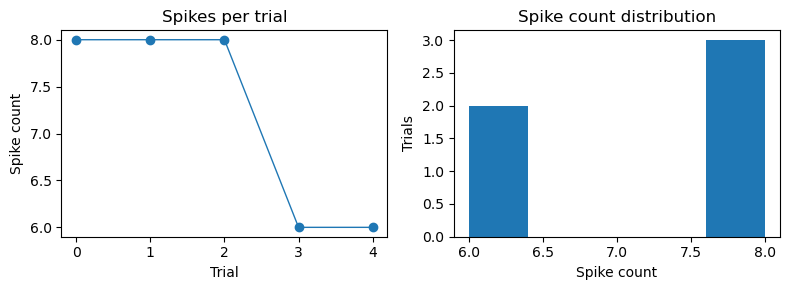

In [17]:
# --- Quick stats: spikes per trial ---
if run_iclamp_mode:
    print("Skipping spike stats (IClamp mode).")
else:
    from modules_local.analysis import summarize_spike_trials

    plot_trial_stats = True
    trial_stats = summarize_spike_trials(results, plot=plot_trial_stats)
    # trial_stats


# Step 4 — Analyze Results

## Analyze Results:

4.1 **Cell & Synapse Generation**  

4.2 **Input Generation**

4.3 **Simulation Analysis**  

## Extra Modules (below):
4.4 **Loaded Sim Data**    

4.5 **Multi Loaded Sim Data**  

### Step 4.1 Cell & Synapse Generation

In [18]:
if run_iclamp_mode:
    print("Skipping Step 4.1 (IClamp mode).")
else:
    # === Step 4.1: Analyze Cell & Synapse Generation ===
    # Align in-vivo curve to PN stimulation timing (if available)
    stim_group = "pn_exc"
    try:
        timing = groups_cfg.get(stim_group, {}).get("timing", {})
        stim_tstart = timing.get("stim_tstart_ms")
        input_stim = timing.get("input_stim_tstart_ms")
        if stim_tstart is None:
            stim_tstart = sim_cfg.get("stim_start_ms")
        if stim_tstart is not None:
            shift_ms = float(stim_tstart)
            if input_stim is not None:
                shift_ms = float(stim_tstart) - float(input_stim)
            t_s, rate = in_vivo_curve_raw
            in_vivo_curve = (t_s + shift_ms / 1000.0, rate)
    except Exception:
        pass


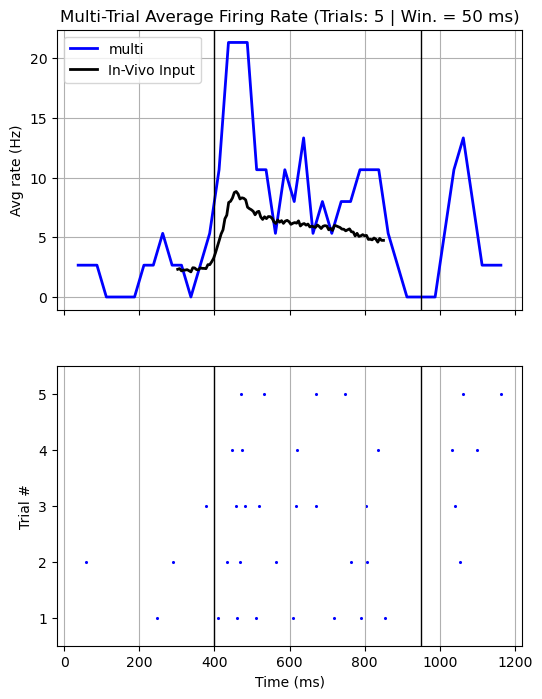

In [19]:
# === Step 4.3: Analyze Single Sim ===
from modules_local import plotting

if run_iclamp_mode:
    plt.figure(figsize=(6, 4))
    plt.plot(T, V, lw=1.5)
    plt.xlabel("Time (ms)")
    plt.ylabel("Vm (mV)")
    plt.title("IClamp test (soma)")
    plt.tight_layout()
else:
    plotting.plot_results(
        results,
        syn_records=results.get("syn_records"),
        in_vivo_curve=in_vivo_curve,
        win_size=50,
        raster_style='dot',
        plot_window=(None, None),  # or (None, None) to auto
    )


# Extra Modules

In [20]:
# (removed stray placeholder)


NameError: name 'err' is not defined

In [ ]:
if run_iclamp_mode:
    print("Skipping comparison (IClamp mode).")
else:
    # === Step 4.4: Compare two runs side-by-side ===
    from pathlib import Path
    from modules_local import run_sim, plotting

    # Set these to two run folder names under output_data (or absolute paths)
    # Accepts: "latest", "previous", "nb_vs_slurm_test", or "output_data/nb_vs_slurm_test"
    run_a_stem = "latest"
    run_b_stem = "previous"

    base = Path.cwd() / "output_data"


    def _fallback_resolve_run_dir(candidate: Path) -> Path:
        if (candidate / 'run_manifest.json').is_file():
            return candidate
        nested = candidate / 'results'
        if (nested / 'run_manifest.json').is_file():
            return nested
        return candidate


    def _collect_run_dirs(base_dir: Path):
        candidates = []
        seen = set()
        if not base_dir.is_dir():
            return candidates
        for p in base_dir.iterdir():
            if not p.is_dir():
                continue
            if '_resolve_run_dir' in globals():
                resolved = _resolve_run_dir(p)
            else:
                resolved = _fallback_resolve_run_dir(p)
            manifest = resolved / 'run_manifest.json'
            if manifest.is_file():
                key = str(resolved)
                if key not in seen:
                    seen.add(key)
                    candidates.append(resolved)
        return sorted(candidates, key=lambda p: (p / 'run_manifest.json').stat().st_mtime)


    def _resolve_run(stem_or_path: str) -> Path:
        p = stem_or_path if isinstance(stem_or_path, Path) else Path(stem_or_path)
        if p.is_absolute():
            return _resolve_run_dir(p) if '_resolve_run_dir' in globals() else _fallback_resolve_run_dir(p)

        runs = _collect_run_dirs(base)
        if stem_or_path in (None, 'latest'):
            if not runs:
                raise FileNotFoundError(f"No run folders found under {base}")
            return runs[-1]
        if stem_or_path in ('previous', 'prev', 'latest-1'):
            if len(runs) < 2:
                raise FileNotFoundError(f"Need at least 2 runs under {base}")
            return runs[-2]

        # Accept "output_data/<name>" by pulling the name after output_data
        try:
            parts = list(p.parts)
            if 'output_data' in parts:
                idx = parts.index('output_data')
                if idx + 1 < len(parts):
                    candidate = base / parts[idx + 1]
                    if candidate.exists():
                        return _resolve_run_dir(candidate) if '_resolve_run_dir' in globals() else _fallback_resolve_run_dir(candidate)
        except Exception:
            pass

        if p.exists():
            return _resolve_run_dir(p) if '_resolve_run_dir' in globals() else _fallback_resolve_run_dir(p)

        candidate = base / stem_or_path
        if candidate.exists():
            return _resolve_run_dir(candidate) if '_resolve_run_dir' in globals() else _fallback_resolve_run_dir(candidate)

        names = [p.name for p in runs]
        raise FileNotFoundError(
            f"Run not found: {stem_or_path!r}. Available under {base}: {names}"
        )


    run_a = _resolve_run(run_a_stem)
    run_b = _resolve_run(run_b_stem)

    res_a = run_sim.load_results(run_a)
    res_b = run_sim.load_results(run_b)

    plotting.plot_compare_side_by_side(
        res_a,
        res_b,
        labels=("Run A", "Run B"),
        win_size=50,
        plot_window=(None, None),
    )


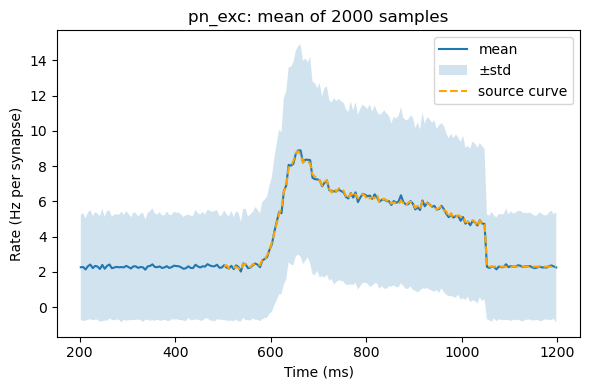

In [ ]:
# Check the input synapse group params
# to check timing and rates look correct
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from modules_local import input_sampling

tune_dir = Path(f"/home/hrbncv/PV-SST/single_cells/cells/{cell_name}/tunes/{model_dir}")
centers, mean_rate, std_rate, sim_cfg, meta, ref_curve = input_sampling.sample_group_rates(
    tune_dir=tune_dir,
    group="sst_inh",
    runs=2000,
    bin_ms=None,
    seed=None,
)


# Save or inspect
df = pd.DataFrame({
    "time_ms": centers,
    "rate_mean_hz": mean_rate,
    "rate_std_hz": std_rate,
})
df.head()

# Plot with source curve overlay (if available)
plt.figure(figsize=(6, 4))
plt.plot(centers, mean_rate, label="mean")
plt.fill_between(centers, mean_rate - std_rate, mean_rate + std_rate, alpha=0.2, label="±std")
if ref_curve:
    ref_t, ref_r = ref_curve
    plt.plot(ref_t, ref_r, "--", color="orange", linewidth=1.5, label="source curve")
plt.xlabel("Time (ms)")
plt.ylabel("Rate (Hz per synapse)")
plt.title(f"{meta['group']}: mean of {meta['n_runs']} samples")
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
# --- Example: save a labeled single run ---
do_save_example = False
if do_save_example:
    from modules_local import run_sim

    results = run_sim.run_sim(cell, geom, sim_cfg, groups_cfg, inputs_by_group)
    # tweak anything you like (color, meta, etc.)
    results["sim_cfg"]["color"] = "m"
    results["meta"]["note"] = "batch 1, bg_exc only"

    run_sim.save_results_with_name(results, "sst2_seg_tuned_bgexc_batch1")


In [ ]:
# --- Example: save a labeled single run ---
do_save_example = False
if do_save_example:
    from modules_local import run_sim

    results = run_sim.run_sim(cell, geom, sim_cfg, groups_cfg, inputs_by_group)
    # tweak anything you like (color, meta, etc.)
    results["sim_cfg"]["color"] = "m"
    results["meta"]["note"] = "batch 1, bg_exc only"

    run_sim.save_results_with_name(results, "sst2_seg_tuned_bgexc_batch1")


In [ ]:
from pathlib import Path
from modules_local import run_sim, plotting

# load directly from disk; ignores current sim_cfg
do_load_results = False
if do_load_results:
    output_stem = "tune1"
    results_name = f"SST2_seg_tuned_{output_stem}.pkl"
    base = Path("output_data")
    run_dir = base / output_stem
    results_file = run_dir / results_name
    legacy_file = base / results_name

    if run_dir.is_dir():
        results_path = run_dir
    elif results_file.is_file():
        results_path = results_file
    elif legacy_file.is_file():
        results_path = legacy_file
    else:
        raise FileNotFoundError(
            f"Set results_path to an existing run folder or file (got {run_dir})"
        )

    results = run_sim.load_results(results_path)

    # optional: tweak plot-only fields such as color
    results["sim_cfg"]["color"] = "m"

    # optional: build in_vivo_curve from current groups_cfg/sim_cfg (if you have them)
    # in_vivo_curve = (delayed_PFR_t, PFR_firing_rate_shortened)

    plotting.plot_results(results, in_vivo_curve=in_vivo_curve)


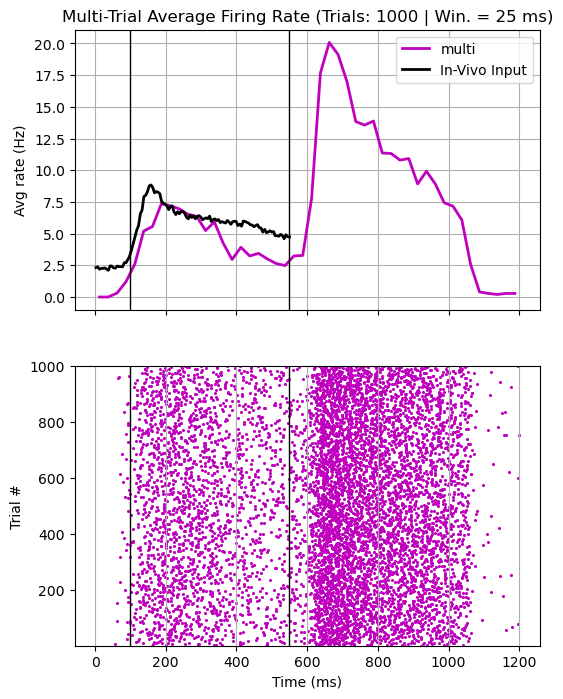

In [ ]:
from pathlib import Path
from modules_local import run_sim, plotting

do_load_old_multi = False
if do_load_old_multi:
    output_stem = "tune1_1000tr1200ms"
    base = Path("/home/hrbncv/PV-SST/single_cells/cells/SST2/tunes/seg_tuned/output_data")
    run_path = base / output_stem / f"SST2_seg_tuned_{output_stem}.pkl"
    legacy_path = base / f"{output_stem}.pkl"

    if run_path.is_file():
        old_path = run_path
    elif legacy_path.is_file():
        old_path = legacy_path
    else:
        raise FileNotFoundError(f"Missing results file under {base}")

    results_old = run_sim.load_old_multi_results(
        old_path,
        label="base tune",
        color="m",      # or whatever you want
        tstop=1200.0,   # ms
        bins=25.0,      # ms
        delay=0.0,      # ms
    )

    # Now this goes through the same plot_results/plot_multi path as new runs
    plotting.plot_results(
        results_old,
        plot_raster=True,
        in_vivo_curve=in_vivo_curve,  # if you want the overlay
    )
